Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

Accessing csv file

In [2]:
df = pd.read_csv("Movies_dataset.csv")

Important infos

In [3]:
# df.columns
# df.info()
# df.describe()
# df.head(2)
# df.tail(2)
# df.isnull().sum()
# df.isnull().mean()*100

🟢 Beginner-Level Questions (Basic Exploration)

How many movies are in the dataset?

In [4]:
print(f"The Total Number of Movies in this Data-set is {df.shape[0]}")

The Total Number of Movies in this Data-set is 449


What is the distribution of movies by year?

In [5]:
df['Year'].value_counts().sort_index(ascending=False)

Year
2025     2
2024     7
2023    17
2022    14
2021     5
        ..
1930     1
1927     1
1926     1
1922     1
1920     1
Name: count, Length: 93, dtype: int64

Which genres appear most frequently?

In [6]:
df['Genre'].value_counts().idxmax()

'Drama'

Who are the top directors with the most movies in the dataset?

<Axes: ylabel='Director'>

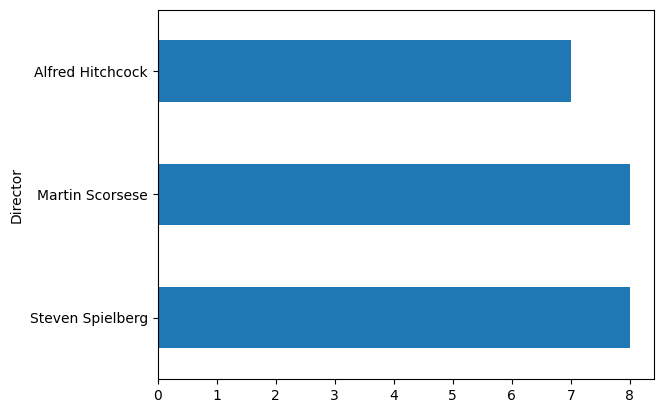

In [7]:
df['Director'].value_counts().head(3).plot(kind="barh")

Which movies have the highest IMDb votes?

In [8]:
top_movie = df['IMDb_Votes'].argmax()
df.loc[top_movie][["Title",'IMDb_Votes']]

Title         Inception
IMDb_Votes      2666368
Name: 215, dtype: object

What are the top 10 movies by Custom_Score?

<Axes: ylabel='Title'>

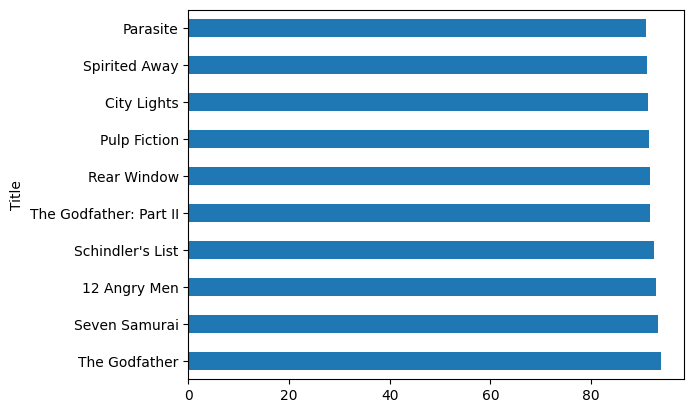

In [9]:
# df[['Custom_Score',"Title"]].sort_values(by='Custom_Score',ascending=False).head(10)
df.groupby('Title')["Custom_Score"].mean().sort_values(ascending=False).head(10).plot(kind="barh")

🟡 Intermediate-Level Questions (Comparisons & Trends)

Do critics’ ratings (Metacritic, RT) align with audience ratings?

<Axes: >

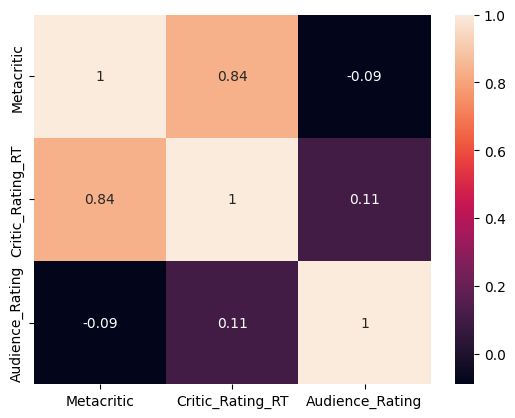

In [10]:
relation = df[['Metacritic','Critic_Rating_RT','Audience_Rating']].corr()
sns.heatmap(relation,annot= True,)

Which genres have the highest average Flickmetrix or Custom_Score?

In [11]:
top_Flicker = df.groupby("Genre")['Flickmetrix_Score'].mean().sort_values(ascending=False).head(3)
print(top_Flicker)
# def split(Multi):
#             return Multi.split(",")
# df["Genre"].apply(split)
top_custom = df.groupby("Genre")['Custom_Score'].mean().sort_values(ascending=False).head(3)
print(top_custom)


Genre
Comedy, Thriller, Drama    91.0
Thriller, Crime            91.0
Drama, War, History        90.0
Name: Flickmetrix_Score, dtype: float64
Genre
Thriller, Crime            91.50
Comedy, Thriller, Drama    90.83
Comedy, War                90.17
Name: Custom_Score, dtype: float64


Are newer movies (after 2010) rated higher or lower than older classics?

         Period  Audience_Rating
0   Before 2010        86.733096
1  2010 & After        83.441667


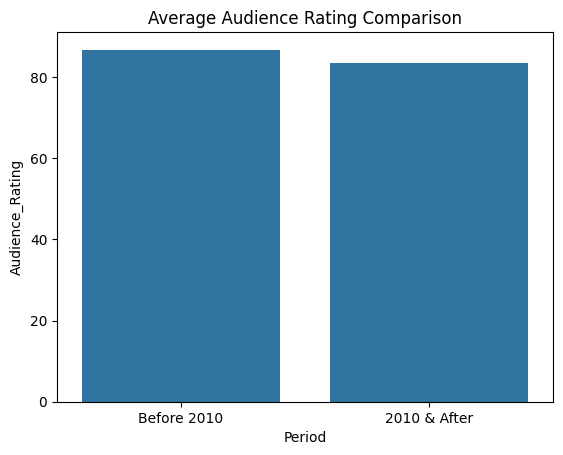

In [12]:
x=df[df["Year"]<2010]["Audience_Rating"].mean()
y=df[df["Year"]>=2010]["Audience_Rating"].mean()

ratings_df = pd.DataFrame({
    "Period": ["Before 2010", "2010 & After"],
    "Audience_Rating": [x, y]
})

print(ratings_df)

sns.barplot(x="Period", y="Audience_Rating", data=ratings_df)
plt.title("Average Audience Rating Comparison")
plt.show()



Which genre has the highest average rating?

<Axes: ylabel='Genre'>

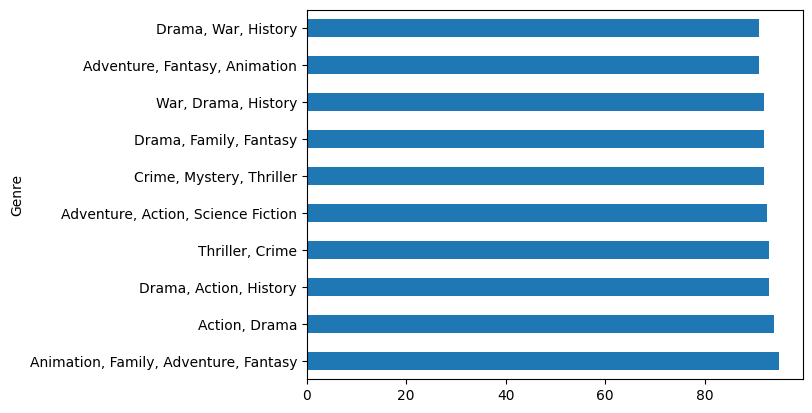

In [13]:
df.groupby("Genre")["Audience_Rating"].mean().sort_values(ascending=False).head(10).plot(kind="barh")

Do critics and audiences agree?

<Axes: xlabel='Critic_Rating_RT', ylabel='Audience_Rating'>

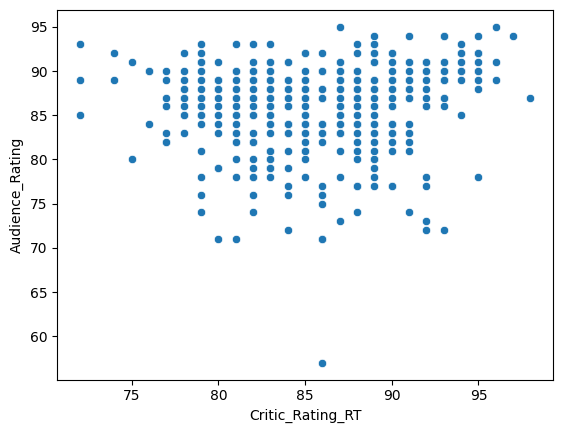

In [14]:
sns.scatterplot(x= 'Critic_Rating_RT', y= 'Audience_Rating', data= df)

Which movies are the most controversial?

<Axes: xlabel='Title', ylabel='Controversy_Score'>

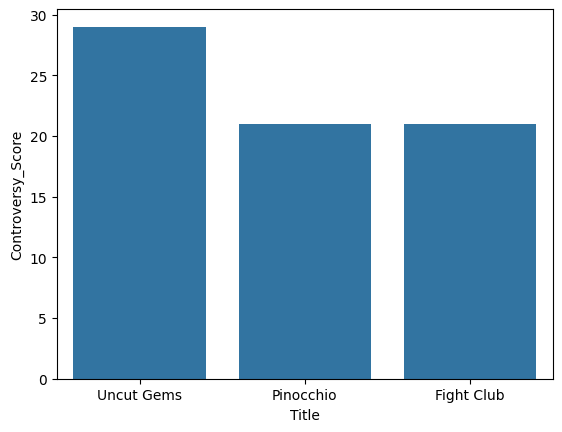

In [15]:
df.columns
# df.head(1)
df["Controversy_Score"] = abs(df['Critic_Rating_RT'] - df['Audience_Rating'])

controversy =( df[["Title","Controversy_Score"]].sort_values(by="Controversy_Score",ascending=False).head(3)
)
sns.barplot(x = "Title", y= "Controversy_Score", data = controversy)

Has movie quality changed over time?

<Axes: xlabel='Year'>

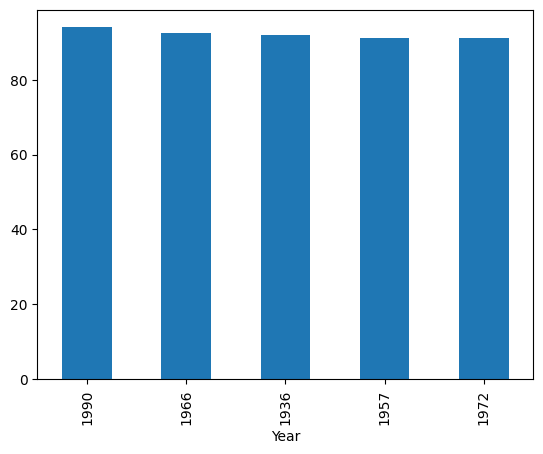

In [16]:
df.groupby("Year")["Audience_Rating"].mean().round(2).sort_values(ascending=False).head(5).plot(kind= "bar")

Do popular movies get better ratings?

<Axes: xlabel='IMDb_Votes', ylabel='Audience_Rating'>

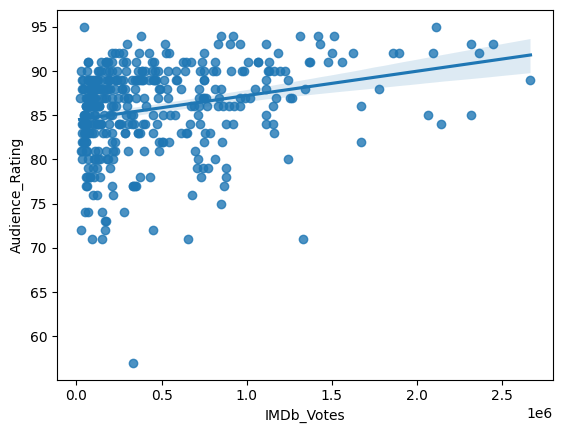

In [26]:
df.columns
relation = df[['IMDb_Votes','IMDb_10','Audience_Rating']].corr()
# plt.subplot(2,2,1)
# sns.heatmap(relation, annot= True)

# plt.subplot(2,2,2)
sns.regplot(x= 'IMDb_Votes', y='Audience_Rating', data=df )

# plt.subplot(2,2,3)
# sns.scatterplot(x= 'IMDb_Votes', y='Audience_Rating', data=df )

Which directors consistently make highly rated movies?

("Directors with fewer than 4 rated movies were excluded to ensure the rankings reflect sustained performance rather than a single highly rated film.")

<Axes: ylabel='Director'>

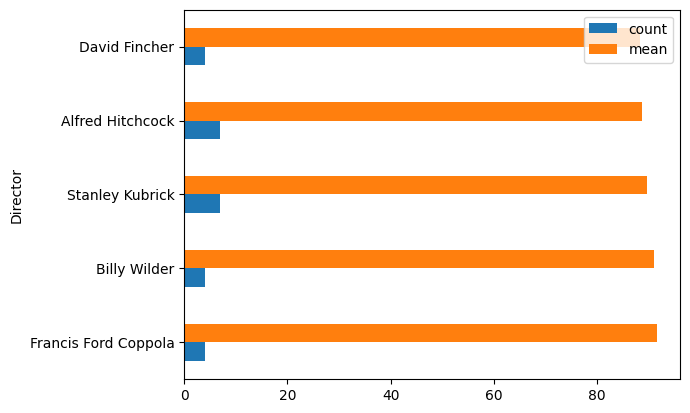

In [57]:
director_stats = (df.groupby("Director")["Audience_Rating"].agg(["count", "mean"]))

director_stats = director_stats[director_stats["count"] > 3]

director_stats.sort_values(by= "mean",ascending=False).head(5).plot(kind="barh")

Do award-winning movies receive higher ratings?

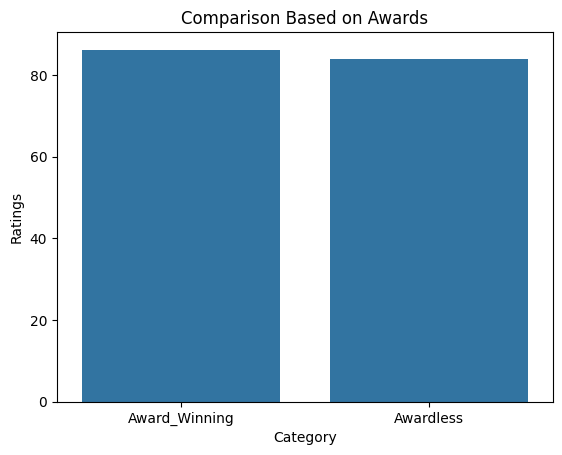

In [75]:
Awardless = df[df['Awards'].isnull()]
Awarded = df[df["Awards"].notnull()]
Awardless_Rating = Awardless["Audience_Rating"].mean()
Awarded_Rating = Awarded["Audience_Rating"].mean()

Award = pd.DataFrame(
{ "Category" : ["Award_Winning" , "Awardless"],
   "Ratings" : [Awarded_Rating ,Awardless_Rating]
}
)
# Award
sns.barplot(x = "Category", y ="Ratings" , data= Award)
plt.title("Comparison Based on Awards")
plt.show()

What influences Custom_Score the most?

In [ ]:
df.corr(numeric_only= True)['Custom_Score'].sort_values(ascending=False)

Custom_Score         1.000000
Flickmetrix_Score    0.957616
IMDb_10              0.713435
IMDb_100             0.713435
Audience_Rating      0.690432
Letterboxd           0.634486
Critic_Rating_RT     0.612147
Metacritic           0.512161
Google_Score         0.329718
IMDb_Votes           0.267163
Letterboxd_Votes     0.105353
Audience_Reviews    -0.066638
Critic_Reviews      -0.166536
Controversy_Score   -0.277538
Year                -0.336219
Rank                -0.964430
Name: Custom_Score, dtype: float64